In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import scipy.stats as stats


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Financial Markets Data/Kenyan Stock Market Data(IPO - 2026)/Safaricom All-Time Daily Data.csv")
df.head()

,time,open,high,low,close,Volume
0,1/18/2012,3.2,3.35,3.20,3.25,0
1,1/19/2012,3.2,3.35,3.20,3.30,0
2,1/20/2012,3.3,3.30,3.30,3.30,0
3,1/23/2012,3.3,3.35,3.25,3.25,0
4,1/24/2012,3.3,3.30,3.20,3.25,0


# Missing Volume Data From 1/18/2012 to 2/20/2012

The Volume data was extracted from a dataset:

https://data.mendeley.com/datasets/5hk4zw32f5/1

In [ ]:
true_volumes = {
    '1/18/2012': 4960000,
    '1/19/2012': 2100000,
    '1/20/2012': 27910000,
    '1/23/2012': 19610000,
    '1/24/2012': 24740000,
    '1/25/2012': 419100,
    '1/26/2012': 5860000,
    '1/27/2012': 25610000,
    '1/30/2012': 936200,
    '1/31/2012': 5670000,
    '2/1/2012': 4160000,
    '2/2/2012': 1850000,
    '2/3/2012': 797600,
    '2/6/2012': 25070000,
    '2/7/2012': 1470000,
    '2/8/2012': 37090000,
    '2/9/2012': 36770000,
    '2/17/2012': 7230000,
    '2/20/2012': 2970000
}

df['time'] = df['time'].astype(str)
zero_volume_mask = df['Volume'] == 0
df.loc[zero_volume_mask, 'Volume'] = df.loc[zero_volume_mask, 'time'].map(true_volumes).fillna(df.loc[zero_volume_mask, 'Volume'])
df['Volume'] = df['Volume'].astype(int)
df.head()

,time,open,high,low,close,Volume
0,1/18/2012,3.2,3.35,3.20,3.25,4960000
1,1/19/2012,3.2,3.35,3.20,3.30,2100000
2,1/20/2012,3.3,3.30,3.30,3.30,27910000
3,1/23/2012,3.3,3.35,3.25,3.25,19610000
4,1/24/2012,3.3,3.30,3.20,3.25,24740000


# Data Addition [IPO(9th June 2008 - Start Of Our Dataset(18th January 2012)]

My Loaded Dataset only reflects data from the 18th January 2012 whereas safaricom first trade date on the NSE was 9th June 2008 at KES 5

In [ ]:
df2 = pd.read_csv("/content/drive/MyDrive/Financial Markets Data/Kenyan Stock Market Data(IPO - 2026)/saf_clean_2008-2012.csv")
df2.head()

,time,open,high,close,low,Volume
0,06/09/2008,5.00,8.00,7.35,6.95,416380000
1,06/10/2008,7.35,8.00,6.95,6.65,127310000
2,06/11/2008,6.95,7.10,6.95,6.90,183490000
3,06/12/2008,6.95,7.50,7.35,7.10,131240000
4,6/13/2008,7.35,7.65,7.45,7.00,250900000


In [ ]:
# Concat the two datasets
df = pd.concat([df2, df], ignore_index=True)
df.head()

,time,open,high,close,low,Volume
0,06/09/2008,5.00,8.00,7.35,6.95,416380000
1,06/10/2008,7.35,8.00,6.95,6.65,127310000
2,06/11/2008,6.95,7.10,6.95,6.90,183490000
3,06/12/2008,6.95,7.50,7.35,7.10,131240000
4,6/13/2008,7.35,7.65,7.45,7.00,250900000


In [ ]:
df.shape

(4505, 6)

In [ ]:
df.dtypes

,0
time,object
open,float64
high,float64
close,float64
low,float64
Volume,int64


In [ ]:
df['time'] = pd.to_datetime(df['time'])

In [ ]:
df.sort_values(by="time")

,time,open,high,close,low,Volume
0,2008-06-09,5.00,8.00,7.35,6.95,416380000
1,2008-06-10,7.35,8.00,6.95,6.65,127310000
2,2008-06-11,6.95,7.10,6.95,6.90,183490000
3,2008-06-12,6.95,7.50,7.35,7.10,131240000
4,2008-06-13,7.35,7.65,7.45,7.00,250900000
...,...,...,...,...,...,...
4500,2026-07-08,35.50,36.00,34.60,34.60,5688012
4501,2026-07-09,35.00,35.20,34.75,34.60,1982946
4502,2026-07-10,35.00,36.00,36.00,34.70,5860627
4503,2026-07-13,36.00,36.20,35.90,35.50,723793


# Adding Two Rows To Get Upto Date Data

I am supposed to model todas volatility (17/07/2026) so the dataset is lacking the last two day

Data Added is from:

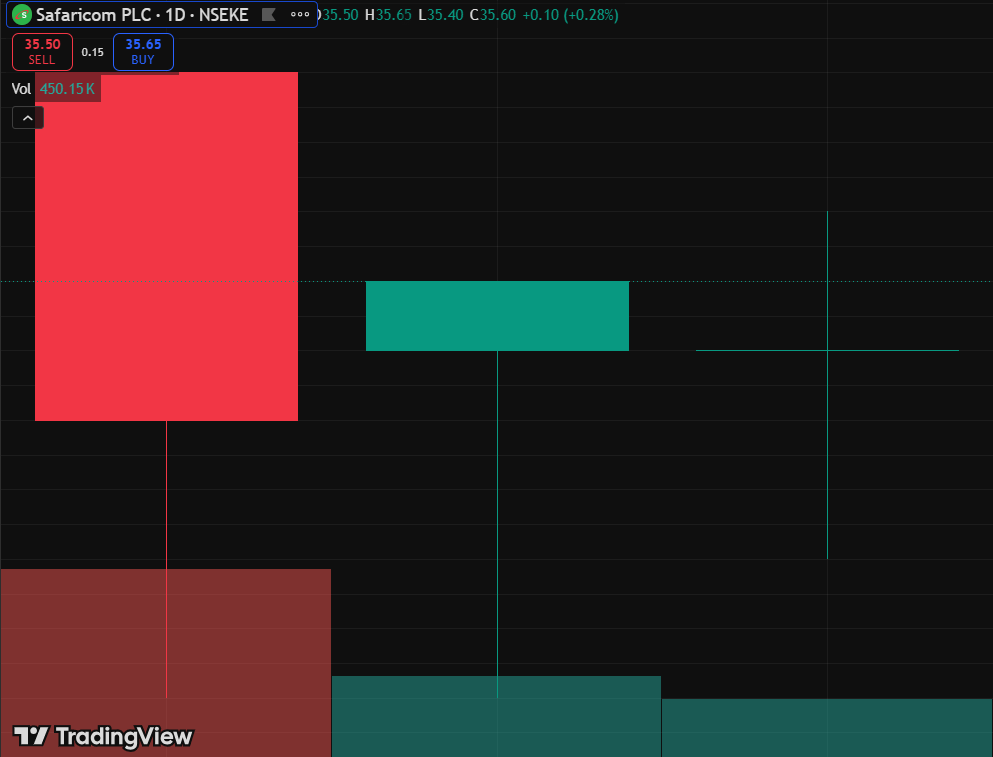

In [ ]:
new_rows = pd.DataFrame([
    {'time': '7/15/2026', 'open': 35.4, 'high': 35.6, 'low': 35.0, 'close': 35.6, 'Volume': 2110726},
    {'time': '7/16/2026', 'open': 35.6, 'high': 35.7, 'low': 35.2, 'close': 35.5, 'Volume': 1529079}
])

new_rows['time'] = pd.to_datetime(new_rows['time'])

df = pd.concat([df, new_rows], ignore_index=True)

df = df.sort_values('time').reset_index(drop=True)

df.tail()

,time,open,high,close,low,Volume
4502,2026-07-10,35.0,36.0,36.0,34.7,5860627
4503,2026-07-13,36.0,36.2,35.9,35.5,723793
4504,2026-07-14,35.9,35.9,35.4,35.0,4861982
4505,2026-07-15,35.4,35.6,35.6,35.0,2110726
4506,2026-07-16,35.6,35.7,35.5,35.2,1529079


# Logarithmic Returns

Log returns are a mathematical trick that forces percentage returns to behave like simple addition. You can just sum up a massive column of daily log returns, and it will give you the exact, perfectly compounded total return for that entire period.


$$
r_t = \ln\!\left(\frac{P_t}{P_{t-1}}\right) = \ln P_t - \ln P_{t-1}
$$

In [ ]:
df['log returns'] = np.log(df['close'] / df['close'].shift(1))

df.head()

,time,open,high,close,low,Volume,log returns
0,2008-06-09,5.00,8.00,7.35,6.95,416380000,NaN
1,2008-06-10,7.35,8.00,6.95,6.65,127310000,-0.055959
2,2008-06-11,6.95,7.10,6.95,6.90,183490000,0.000000
3,2008-06-12,6.95,7.50,7.35,7.10,131240000,0.055959
4,2008-06-13,7.35,7.65,7.45,7.00,250900000,0.013514


In [ ]:
df['simple returns'] = df['close'].pct_change()
df.head()

,time,open,high,close,low,Volume,log returns,simple returns
0,2008-06-09,5.00,8.00,7.35,6.95,416380000,NaN,NaN
1,2008-06-10,7.35,8.00,6.95,6.65,127310000,-0.055959,-0.054422
2,2008-06-11,6.95,7.10,6.95,6.90,183490000,0.000000,0.000000
3,2008-06-12,6.95,7.50,7.35,7.10,131240000,0.055959,0.057554
4,2008-06-13,7.35,7.65,7.45,7.00,250900000,0.013514,0.013605


In [ ]:
# subplots grid
fig = make_subplots(rows=3, cols=1,
                    # subplot titles
                    subplot_titles=['Close Price Trend', 'Log Returns Trend', 'Simple Returns Trend'])


fig1 = px.line(data_frame=df, x='time', y='close')
fig2 = px.line(data_frame=df, x='time', y='log returns')
fig3 = px.line(data_frame=df, x='time', y='simple returns')

fig.add_trace(fig1.data[0], row=1, col=1)
fig.add_trace(fig2.data[0], row=2, col=1)
fig.add_trace(fig3.data[0], row=3, col=1)

fig.show()

In [ ]:

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=['The Mathematical Function', 'The Q-Q Probability Plot']
)

x_vals = np.linspace(-0.99, 3.0, 100)

# Add f(x) = x (Simple Returns) to Row 1, Col 1
fig.add_trace(
    go.Scatter(x=x_vals, y=x_vals, mode='lines', name='f(x) = x', line=dict(color='red')),
    row=1, col=1
)

# Add f(x) = log(1+x) (Log Returns) to Row 1, Col 1
fig.add_trace(
    go.Scatter(x=x_vals, y=np.log(1 + x_vals), mode='lines', name='f(x) = log(1+x)', line=dict(color='blue')),
    row=1, col=1
)

# Add the dotted origin crosshairs
fig.add_hline(y=0, line_dash="dot", line_color="black", line_width=1, row=1, col=1)
fig.add_vline(x=0, line_dash="dot", line_color="black", line_width=1, row=1, col=1)


# Let SciPy calculate the theoretical coordinates in the background
(osm_sim, osr_sim), (slope_sim, intercept_sim, r_sim) = stats.probplot(df['simple returns'].dropna(), dist="norm")
(osm_log, osr_log), (slope_log, intercept_log, r_log) = stats.probplot(df['log returns'].dropna(), dist="norm")

# Add Simple Returns dots to Row 1, Col 2
fig.add_trace(
    go.Scatter(x=osm_sim, y=osr_sim, mode='markers', name='Returns', marker=dict(color='blue', opacity=0.5, symbol='circle')),
    row=1, col=2
)

# Add the Theoretical Normal Distribution Line (using the simple return's slope)
fig.add_trace(
    go.Scatter(x=osm_sim, y=(slope_sim * osm_sim) + intercept_sim, mode='lines', name='Normal Distribution', line=dict(color='red')),
    row=1, col=2
)

# Add Log Returns 'x' marks to Row 1, Col 2
fig.add_trace(
    go.Scatter(x=osm_log, y=osr_log, mode='markers', name='Log returns', marker=dict(color='blue', opacity=0.5, symbol='x')),
    row=1, col=2
)

# ==========================================
# CLEANUP & FORMATTING
# ==========================================
# Label the axes for the left chart
fig.update_xaxes(title_text="f(x)", row=1, col=1)
fig.update_yaxes(title_text="x", row=1, col=1)

# Label the axes for the right chart
fig.update_xaxes(title_text="Theoretical quantiles", row=1, col=2)
fig.update_yaxes(title_text="Observed quantiles", row=1, col=2)

# Set the overall size and theme
fig.update_layout(height=500, width=1000, template="plotly_white")

fig.show()

# Volatility Clustering In Financial Markets

Volatility clustering is a well-known effect in equity markets. In simple meaning, volatility clustering refers to a tendency of large changes in asset prices to follow large changes and small changes in asset prices to follow small changes.

### Simulation

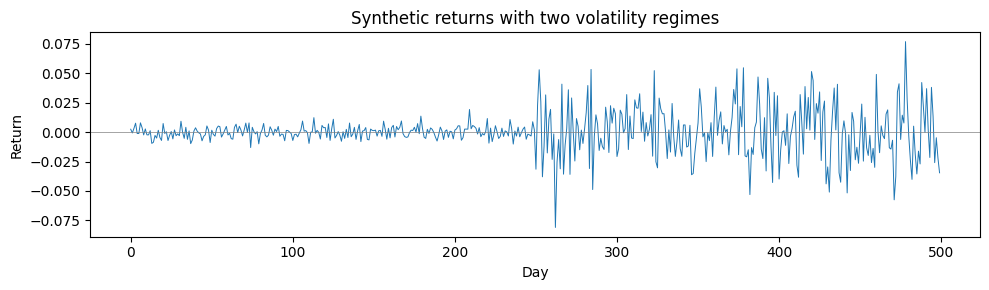

In [38]:
np.random.seed(42)
n = 500

# Simulate two regimes: low-vol and high-vol
low_vol = np.random.normal(0, 0.005, n // 2)
high_vol = np.random.normal(0, 0.025, n // 2)
synthetic_returns = np.concatenate([low_vol, high_vol])

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(synthetic_returns, linewidth=0.7)
ax.set_title("Synthetic returns with two volatility regimes")
ax.set_xlabel("Day")
ax.set_ylabel("Return")
ax.axhline(0, color="gray", linewidth=0.5)
plt.tight_layout()
plt.show()

# Insights

Volatility clustering is just the mathematical observation that the market rarely switches from a +0.2% day straight to a -5% day and back to a +0.1% day.

# Volatility Clustering On Safaricom Data

### Absolute Log Return

This ignores whether the log return value is positive or negative because volatility is about the size of the movement, not its direction.

In [40]:
df['absolute log return'] = np.abs(df['log returns'])

fig = px.line(data_frame=df, x='time', y='absolute log return')

fig.show()


### Moving Averages

This helps to show the volatility trend clearly

In [41]:
df['30 moving average'] = df['absolute log return'].rolling(window=30).mean()

In [43]:
fig = px.line(data_frame=df, x='time', y='30 moving average')

fig.show()

# Insights

This shows the magnitude of the movement not the statistical etimate since volatility is a standard deviation of log returns

# Statistical Estimate Of Volatility (Rolling Standard Deviation)

In [44]:
df['21-day rolling volatility'] = df['log returns'].rolling(window=21).std()

fig = px.line(data_frame=df, x='time', y='21-day rolling volatility')

fig.show()

# This Proves Volatility Clustering (Moving averages & Rolling Volatility )

###  large price movements to be followed by more large price movements and low price movements are followed by more low price movements

In [45]:
df.to_csv('/content/drive/MyDrive/safaricom_stock_data(IPO - 2026).csv')